<a href="https://colab.research.google.com/github/Aeshah-A/lab1/blob/main/imgPHWLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#1. Create a synthetic image containing at least two objects

image = np.zeros((225, 225))
image[120:170, 30:80] = 255 # Object 1
image[20:70, 50:100] = 128 # Object 2
image[100:150, 150:200] = 200 # Object 3

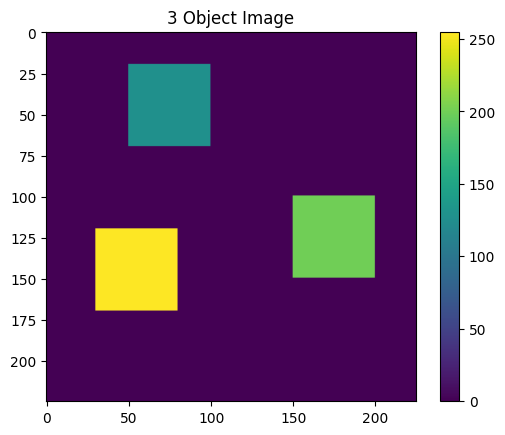

In [3]:
plt.imshow(image)
plt.title("3 Object Image")
plt.colorbar()
plt.show()

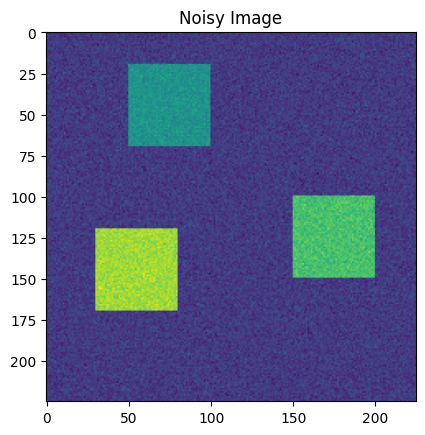

In [4]:
#2. Add noise to the image

noise = np.random.normal(0, 15, image.shape)
noisy = image + noise

plt.imshow(noisy)
plt.title("Noisy Image")
plt.show()

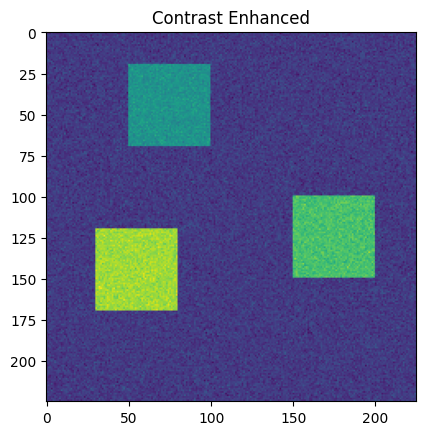

In [5]:
#3. Apply enhancement and denoising

min_val = noisy.min()
max_val = noisy.max()
enhanced = (noisy - min_val) / (max_val - min_val) * 255
plt.imshow(enhanced)
plt.title("Contrast Enhanced")
plt.show()

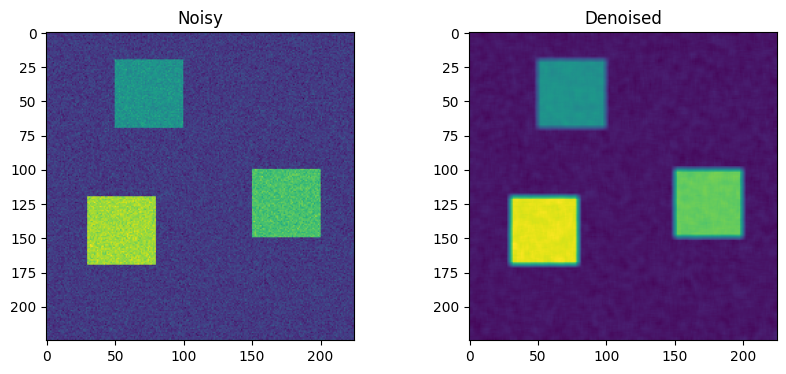

In [6]:
def mean_filter(img, k=5):
    pad = k // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = padded[i:i+k, j:j+k].mean()
    return output

denoised = mean_filter(noisy)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(noisy)
plt.title("Noisy")

plt.subplot(1,2,2)
plt.imshow(denoised)
plt.title("Denoised")
plt.show()

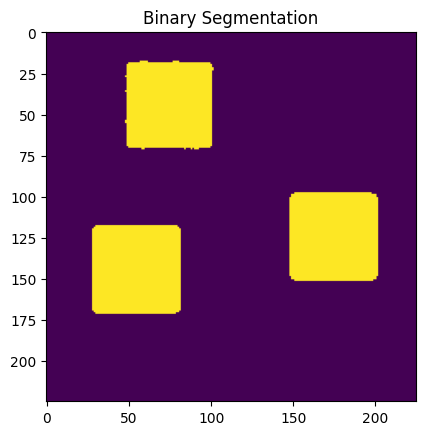

In [7]:
#4. Segment the objects using a threshold

threshold = denoised.mean()
binary = denoised > threshold

plt.imshow(binary)
plt.title("Binary Segmentation")
plt.show()